# Simulating a random process based on the target correlation function 

This code demonstrates how to generate a sample random process based on the correlation function, as we discussed in the lecture video. Note that we already used this code when we were trying to estimate the correlation function and correlation length based on data, but I did not give you a lot of detail about how the simulation process works. This code is more clearly commented in this regard.  

# Step 1: Import the necessary packages, initialize the random process, and set input parameters
First, we need to import the numpy packages that will be used subsequently in this code. Then we identify the length of the specimen and the number of points of our simulated random process. You can play with these once you have gone through the code, but for now you might want to leave the values as listed below. The simulated sample is a function of time, so we also initialize the time vector, with N1+1 evenly spaced points between 0 and sample length L1. 

In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

# Define input parameters
L1=10 #Length of the process
N1=1000 #Number of points on the process

# Initialize the time vector
t=np.linspace(0,L1,N1+1)
dt=t[2]-t[1]

# Step 2: Set up functions to generate a sample random process

The following code generates a single sample of a stationary 1D Gaussian random process with mean 0 and variance Var. If a different mean is needed, this is easily accomplished by adding the value of the mean to every entry in the sample random process. The parameter b, which described the correlation function, dictates the correlation length. 

## Generate a function to formulate the covariance matrix
Using the covariance function, we first want to generate the covariance matrix, so that we can calculate the eigenvalues/eigenvectors of this covariance matrix for simulating a vector of correlated Gaussian random variables. The (i,j) component of the matrix indicates the covariance between $X(t_i)$ and $X(t_j)$, the random process at two different points in time. In our case, we will assume the covariance function has the form $B(\tau)=\sigma_X^2b^2/(b^2+\tau^2)$. The code can be updated easily to incorporate a different covariance function, if desired.

In [2]:
def covmat (b,N,L,S2):

# Set up a vector of lags from -N to N
    lags=np.divide(np.multiply(np.arange(-N,N+1),L),N)

# Generate a vector acovvec containing the covariance function corresponding to each value listed in the vector lags
    #numerator of the covariance function is b^2. Make it a vector of length 2*N+1, with each entry equal to b^2.
    bvecsq=np.multiply(np.power(b,2),(2*N+1)*[1])
    #denom=b^2+np.power(lags,2). This is a vector of length 2*N+1. Divide numerator by denominator to get a vector 
    #of length 2*N1+1 that contains the correlation function for every lag from -N to N.
    acorvec=np.divide(bvecsq,(bvecsq+np.power(lags,2)))
    #multiply the correlation vector acorvec by the variance of the random process, to get the covariance vector.
    acovvec=np.multiply(acorvec,S2)
    
# Generate a matrix acovmat containing the covariance matrix describing the random process at all values in the
#  lags vector
    # Define the first row of acovmat as acovvec
    acovmat=acovvec.reshape(1,2*N+1)
    # Each column of the covariance matrix will be the covariance vector shifted by one place from the previous 
    # column. First, initialize a running vector tmpshftacov to start as the covariance vector acovvec, 
    # and also initialize shftacov to be the same type as acovvec.
    tmpshftacov=acovvec
    shftacov = np.empty_like(acovvec)
    # Loop over 0:N and shift all the elements in vector shftacov by 1, then append this vector onto the matrix acovmat
    # Make all the elements before the shift equal to 0
    for l in np.arange(N): 
        shftacov[:1] = 0
        shftacov[1:] = tmpshftacov[:-1]
        acovmat=np.append(acovmat, shftacov.reshape(1, 2*N+1), axis=0)
        tmpshftacov=shftacov
    # Delete the columns that include zeros, so acovmat is an (N+1)x(N+1) matrix, with the value Var on the diagonals
    acovmat=np.delete(acovmat,slice(0,N),axis=1)
    
    return acovmat

## Formulate the covariance matrix and find its eigenvalues and eigenvectors
To generate a vector of correlated random variables, we will need to find the eigenvalues of the covariance matrix.


In [3]:
def eigan(acovmat):#Calculate eigenvalues and eigenvectors of the covariance matrix
    eval,evec=eig(acovmat)
    return eval,evec

## Define a function to generate a random process
This function generates a process with parameter b and variance Var, which is related the correlation length, with N+1 values at discrete, evenly spaced points over sample length L.  

In [4]:
def simulation(N,L,b,Var):
    acovmat=covmat(b,N1,L1,Var)
    eval,evec=eigan(acovmat)
    zvals=np.multiply(np.random.normal(0,1,N+1),np.power(eval,.5))
    xvals=np.matmul(evec,zvals)
    #print('size')
    #print(np.size(xvals))
    return np.real(xvals)


## Generate 3 random processes with the same variance and parameter b
First, the code will generate 3 different processes with the same variance Var and parameter b. 

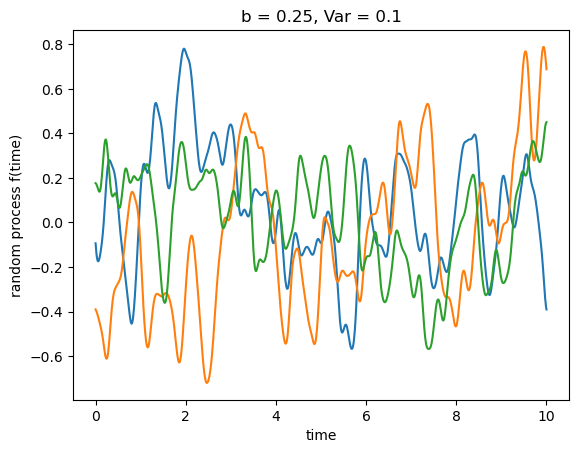

In [5]:
Var=0.1 #Variance of the process
b=.25 #Parameter of the correlation function
#Plot multiple samples with the same b and Var
f=simulation(N1,L1,b,Var)
plt.plot(t,f)
f=simulation(N1,L1,b,Var)
plt.plot(t,f)
f=simulation(N1,L1,b,Var)
plt.plot(t,f)
plt.xlabel('time')
plt.ylabel('random process f(time)')
plottitle="b = {}, Var = {}".format(b,Var)
plt.title(plottitle)
plt.show()

## Generate 3 random processes with the same parameter b but different variance
What happens to the samples as the variance is increased?

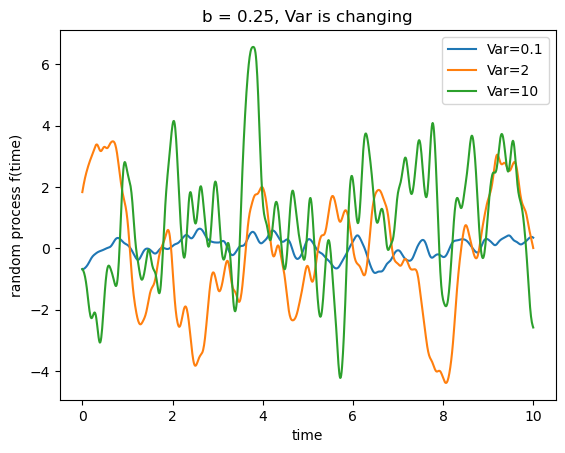

In [6]:
#Plot multiple samples with the same b but different Var
Var=0.1 #Variance of the process
f=simulation(N1,L1,b,Var)
plt.plot(t,f)
Var=2 #Variance of the process
f=simulation(N1,L1,b,Var)
plt.plot(t,f)
Var=10 #Variance of the process
f=simulation(N1,L1,b,Var)
plt.plot(t,f)
plt.xlabel('time')
plt.ylabel('random process f(time)')
plottitle="b = {}, Var is changing".format(b)
plt.title(plottitle)
plt.legend(['Var=0.1', 'Var=2', 'Var=10'])
plt.show()


## Generate 3 random processes with the same variance but different parameter b
What happens to the sample processes as b increases?

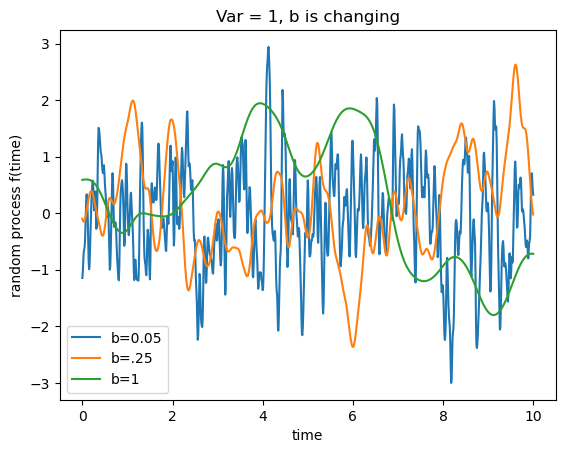

In [7]:
#Plot multiple samples with the same Var but different b
Var=1 #Variance of the process
b=.05 #Parameter of the correlation function
f=simulation(N1,L1,b,Var)
plt.plot(t,f)
b=.25 #Parameter of the correlation function
f=simulation(N1,L1,b,Var)
plt.plot(t,f)
b=1 #Parameter of the correlation function
f=simulation(N1,L1,b,Var)
plt.plot(t,f)
plt.xlabel('time')
plt.ylabel('random process f(time)')
plottitle="Var = {}, b is changing".format(Var)
plt.title(plottitle)
plt.legend(['b=0.05', 'b=.25', 'b=1'])
plt.show()